# Add-Module sensitivity sweep — $n \times k$

**Mechanism.** The Add Module improves a bundle by having the LLM generate **$n$ candidate item
descriptions** (the *expand* step); each description retrieves its **top-$k$** semantically-similar
catalog items via cosine k-NN → **$n \times k$** candidate items (plus the bundle's remaining
session items) are fed into the ADD prompt, which picks the single best addition.

**Confirmed default (from the code): $n=3$, $k=2$ → 6 candidates** (retrieval is top-**2**).

This notebook runs the canonical (no-graphs) LLM4BEAR workflow over a **grid $n\in\{1,3,5\}$,
$k\in\{1,2,5\}$ (9 configs)** on the **first 100 electronic bundles, $T=10$ iterations**, and
reports per config: **high-quality completion rate**, **mean evaluation score $\bar{s}$**, and
**token cost** (plus average refinement iterations for the separate Reviewer-4 ask). Outputs a
$3\times3$ heatmap over these metrics.

> We report completion rate and $\bar{s}$ for the sensitivity analysis; $N_\text{eff}$ is a
> corpus-level diversity measure and is unreliable on the subsampled grid, so we evaluate it only on
> the full dataset (§X).

*Self-contained: git-clones its own data and reads the API key from Colab Secrets. Watch the
per-iteration prints below each run.*

In [ ]:
# 1. Dependencies (Colab already has numpy/pandas/matplotlib)
!pip -q install openai sentence-transformers numba

In [ ]:
# 2. OpenAI key from Colab Secrets (Runtime > Secrets: add API_KEY). Mirrors LLM4BEAR_Refinement.
import os
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("API_KEY")
    print("API key loaded from Colab Secrets.")
except Exception as e:
    # Local fallback: set os.environ["OPENAI_API_KEY"] yourself before running.
    assert os.environ.get("OPENAI_API_KEY"), f"Set OPENAI_API_KEY (Colab Secrets 'API_KEY'): {e}"

API key loaded from Colab Secrets.


In [ ]:
# 3. Data: sparse clone (BundleRec Data + 2_Bundle Refinement)
import os
if not os.path.isdir("/content/LLM4BEAR"):
    !git clone --depth 1 --filter=blob:none --sparse https://github.com/anon5159753/LLM4BEAR.git /content/LLM4BEAR
    !cd /content/LLM4BEAR && git sparse-checkout set "BundleRec Data" "2_Bundle Refinement"
else:
    print("/content/LLM4BEAR already present")

Cloning into '/content/LLM4BEAR'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 81 (delta 10), reused 76 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 44.28 KiB | 8.86 MiB/s, done.
Resolving deltas: 100% (10/10), done.
remote: Enumerating objects: 1, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 1 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (1/1), 9.97 KiB | 9.97 MiB/s, done.
remote: Enumerating objects: 163, done.
remote: Counting objects: 100% (163/163), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 163 (delta 36), reused 161 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (163/163), 108.41 MiB | 10.86 MiB/s, done.
Resolving deltas: 100% (36/36), done.
Updating files: 100% (320/320), done.


## Canonical workflow, inlined & parameterized for $n$, $k$

The cell below is the canonical `no_graphs` LLM4BEAR pipeline (evaluators → filter → diagnose →
add/remove → re-evaluate), inlined self-contained. Two knobs are threaded through
`bundle_refinement_workflow(..., n_expand, k_retrieve)`:
`create_expand_candidates_prompt(..., n)` (how many descriptions) and
`extended_candidates_extractor(..., num_candidates=k)` (top-k retrieved per description).
`single_request` also tallies token usage for the cost metric.

In [12]:
# 4. === Inlined LLM4BEAR canonical workflow (parameterized for n, k) ===
# ===== Auto-assembled inline library for the Add-Module n x k sweep (Colab) =====
import asyncio, copy, json, pickle, random, os
import numpy as np
import pandas as pd
from numba import jit
from pathlib import Path

# --- config constants (were config.py) ---
MODEL = "gpt-4o-mini"
TEMPERATURE = 0
MAX_TOKENS = 8000
SEED = 42
BATCH_SIZE = 128
EMBED_MODEL = "intfloat/e5-large-v2"

# Colab data layout: repo is sparse-cloned to /content/LLM4BEAR
REPO_ROOT = Path(os.environ.get("LLM4BEAR_REPO_ROOT", "/content/LLM4BEAR"))
BUNDLEREC_DATA = REPO_ROOT / "BundleRec Data"
REFINEMENT_DIR = REPO_ROOT / "2_Bundle Refinement"
REFINEMENT_FINAL_PROMPTS = REFINEMENT_DIR / "final_prompts"
OUTPUT_DIR = Path("output")
def ensure_output_dir():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True); return OUTPUT_DIR

# API key: set OPENAI_API_KEY before importing (Colab: from google.colab import userdata; ...)
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")

# --- token/cost accounting (accumulated across a run; reset per config) ---
TOKENS = {"in": 0, "out": 0, "calls": 0}
def reset_tokens():
    TOKENS["in"] = 0; TOKENS["out"] = 0; TOKENS["calls"] = 0
# gpt-4o-mini pricing (USD per token)
PRICE_IN = 0.15 / 1_000_000
PRICE_OUT = 0.60 / 1_000_000
def current_cost_usd():
    return TOKENS["in"] * PRICE_IN + TOKENS["out"] * PRICE_OUT

# --- OpenAI client (lazily built so importing this module never needs a key) ---
_async_client = None


def get_async_client():
    """Return a process-wide AsyncOpenAI client, building it on first use."""
    global _async_client
    if _async_client is None:
        from openai import AsyncOpenAI

        key = OPENAI_API_KEY
        if not key:
            raise RuntimeError(
                "OPENAI_API_KEY is not set. Put it in a .env file or the environment "
                "before running a stage that calls the OpenAI API."
            )
        _async_client = AsyncOpenAI(api_key=key)
    return _async_client


async def single_request(user, system=None, seed_value=None):
    """One chat completion with exponential-backoff retry."""
    import openai

    client = get_async_client()
    if system:
        message = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    else:
        message = [{"role": "user", "content": user}]

    for delay_secs in (2 ** x for x in range(0, 3)):
        try:
            response = await client.chat.completions.create(
                model=MODEL,
                messages=message,
                temperature=TEMPERATURE,
                max_tokens=MAX_TOKENS,
                seed=seed_value,
            )
            u = getattr(response, 'usage', None)
            if u is not None:
                TOKENS['in'] += getattr(u, 'prompt_tokens', 0) or 0
                TOKENS['out'] += getattr(u, 'completion_tokens', 0) or 0
                TOKENS['calls'] += 1
            return response.choices[0].message.content.strip()
        except openai.OpenAIError as e:
            jitter = random.randint(0, 1000) / 1000.0
            sleep_dur = delay_secs + jitter
            print(f"Error: {e}. Retrying in {round(sleep_dur, 2)} seconds.")
            await asyncio.sleep(sleep_dur)

    return None  # all retries failed


async def openai_request(prompts, system=None, batch_size=BATCH_SIZE, delay=0):
    """Run a list of ``{"prompts": <user text>}`` dicts in batches, seed=42."""
    results = []
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i:i + batch_size]
        tasks = [single_request(d["prompts"], system=system, seed_value=SEED) for d in batch]
        batch_results = await asyncio.gather(*tasks)
        results.extend(batch_results)
        print(f"✅ Sending batch {i // batch_size + 1} — sleeping for {delay}s...\n")
        await asyncio.sleep(delay)
    return results


# --- Response parsing (the LLM emits a ===JSON_START=== separator) ---
def extract_json_simple_replace(response_text):
    """Parse the JSON object that follows a '===JSON_START===' separator."""
    try:
        json_part = response_text.split("===JSON_START===")[1]
        first_brace = json_part.find("{")
        last_brace = json_part.rfind("}")
        json_string = json_part[first_brace: last_brace + 1]
        return json.loads(json_string)
    except IndexError:
        print("Error: The separator '===JSON_START===' was not found.")
        return None
    except json.JSONDecodeError:
        print("Error: Could not find or parse a valid JSON object after the separator.")
        return None


def extract_reasoning_part(response_text):
    """Return the analysis text that appears before the '===JSON_START===' separator."""
    return response_text.split("===JSON_START===")[0].strip()


def extract_json_from_response(response_text):
    """Return the substring from the first '{' to the last '}', or None."""
    start_index = response_text.find("{")
    end_index = response_text.rfind("}")
    if start_index != -1 and end_index != -1:
        return response_text[start_index: end_index + 1]
    return None


def extract_bundle_score(response):
    json_schema = extract_json_simple_replace(response)
    if json_schema is not None:
        try:
            return float(json_schema["score"])
        except Exception:
            return None
    return None


def extract_bundle_verdict(response, consideration):
    json_schema = extract_json_simple_replace(response)
    if json_schema is None:
        return None
    try:
        if consideration == "1-2":
            v1 = json_schema["is_poor_quality_bundle"]
            v2 = json_schema["is_acceptable_quality_bundle"]
        elif consideration == "3":
            v1 = json_schema["needs_improvement_bundle"]
            v2 = json_schema["is_good_quality_bundle"]
        elif consideration == "4-5":
            v1 = json_schema["needs_improvement_bundle"]
            v2 = json_schema["is_high_quality_bundle"]
        else:
            return None
        return [v1.lower(), v2.lower()]
    except Exception:
        return None


def input_strings(intent_list, item_list):
    """Format (intent, items) pairs into 'Intent: ...\\nBundle Items:\\n1. ...' strings."""
    string_list = []
    for i in range(len(intent_list)):
        intent = intent_list[i]
        items = item_list[i]
        item_str = "\n".join([f"{j + 1}. {title}" for j, title in enumerate(items)])
        string_list.append(f"Intent: {intent}\nBundle Items:\n{item_str}\n")
    return string_list


@jit(nopython=True)
def matrix_cosine_line_jit(embeddings, new_embedding):
    """Cosine similarity of ``new_embedding`` against every row of ``embeddings``."""
    n = embeddings.shape[0]
    norms = np.sqrt(np.sum(embeddings ** 2, axis=1))
    new_norm = np.sqrt(np.sum(new_embedding ** 2))
    cosine_similarity_line = np.zeros((n), dtype=np.float32)
    for i in range(n):
        cosine_similarity_line[i] = np.dot(embeddings[i], new_embedding) / (norms[i] * new_norm)
    return cosine_similarity_line


def stochastic_decision(bundle_items):
    """Fallback add/remove decision when the LLM's operation is unusable."""
    l = len(bundle_items)
    if l == 2:
        return "add"
    elif l > 8:
        return "remove"
    else:
        chance_to_add = 0.65 + (3 - l) * 0.1
        return "add" if random.random() < chance_to_add else "remove"



# ===== prompt text functions (from LLM4BEAR_Refinement cells 9/22/14) =====
def drugs_prompt(bundle_str, reasoning1, reasoning2, reasoning3, average_score, min_score):
    """
    Generates a prompt for an LLM to analyze and propose a fix for a poorly-rated bundle.

    Args:
        bundle_items (list): A list of strings representing the items in the bundle.
        reasoning1 (str): The reasoning from the first evaluator.
        reasoning2 (str): The reasoning from the second evaluator.
        reasoning3 (str): The reasoning from the third evaluator.

    Returns:
        str: The fully formatted prompt string.
    """
    # Format the list of items into a clean string for the prompt
    # bundle_items_str = ", ".join(bundle_items)

    # Use a triple-quoted f-string to build the multi-line prompt

    adding_metrics = "\nFunctionality Integration: Describe how a user would utilize this collection of items to achieve their primary goal. Considering the entire workflow, is this a complete and logical set of items for the task, or is there an irrelevant or missing item? \n"\
              "Similarity: What is the common theme or category that connects these items?\n"\
              "Complementarity: Are these items more valuable together than they would be if sold separately? Does the presence of one item create a clear reason to buy the other(s)?\n"\
              "Diversity: Does the variety of items in this bundle cater to a broad set of related needs for a single user, or does the mix of items seem unfocused and random?\n"


    prompt = f"""You are an Expert Bundle Designer with years of experience creating successful and coherent product packages. Your task is to analyze a failing bundle and capture all nuances given by the experts.

**## CONTEXT:**
You have received a bundle that was reviewed by three different evaluators. The bundle's quality score is not high enough.


{bundle_str}
* **Average Score:** {average_score}
* **Min Score:** {min_score}

* **Evaluator 1 Reasoning:**
{reasoning1}

* **Evaluator 2 Reasoning:**
{reasoning2}

* **Evaluator 3 Reasoning:**
{reasoning3}

---

**## YOUR TASK: Problem Analysis**

You must perform the following four steps:

1.  **Synthesize the Core Problem:** Read all three evaluator reasonings and combine them into a single, concise **Problem Statement**. This statement should identify the bundle's single biggest flaw (e.g., "The bundle lacks a cohesive theme," "It's missing an essential item," or "An item is incompatible with the rest").

2.  **List the Top 3 Flaws:** Based on your analysis and the evaluator feedback, list the three most significant reasons that contribute to the core problem you identified.

3. **Evaluate Metrics:** Give verdict of low, medium, high for each metric below.
{adding_metrics}

4. **Operation Decision:** Decide whether to add or remove items from the bundle depending on the verdict of each metric.
If low Functionality Integration: Add or remove items to be able to fulfill intended purpose of bundle.
If low Similarity: Add more items that are thematic to the intent.
If low Complementarity: Remove the noisy item.
If low Diversity: Add a more niche item that is thematic to the intent.

---

**## OUTPUT FORMAT:**
After you have completed your full written analysis, print the separator string `===JSON_START===` on a new line. Then, on the next line, provide a single JSON object that summarizes your conclusions. Do not include any other text after the separator.

**JSON Schema:**
```json
{{
  "problem_summary": "string",
  "Functionality Integration: string, must be low/medium/high",
  "Similarity: string, must be low/medium/high",
  "Complementarity: string, must be low/medium/high",
  "Diversity: string, must be low/medium/high",
  "operation": "string, must be add/remove ONLY PICK ONE",
  "new_bundle_intent": "string,  a concise 3 or 4 word summary of the intended direction of the new, improved bundle's theme and purpose. The intent must be specific and not a broad category. Do not include phrases like 'and accessories' or 'and tools'."
}}
````
"""

    return prompt


def create_remove_item_prompt(bundle_str, summary, average_score, min_score):
    """
    Generates a prompt for an LLM to analyze and propose a fix for a poorly-rated bundle.

    Args:
        bundle_items (list): A list of strings representing the items in the bundle.
        reasoning1 (str): The reasoning from the first evaluator.
        reasoning2 (str): The reasoning from the second evaluator.
        reasoning3 (str): The reasoning from the third evaluator.

    Returns:
        str: The fully formatted prompt string.
    """
    # Format the list of items into a clean string for the prompt
    # bundle_items_str = ", ".join(bundle_items)

    # Use a triple-quoted f-string to build the multi-line prompt
    prompt = f"""You are an Expert Bundle Designer with years of experience creating successful and coherent product packages. Your task is to analyze a failing bundle and decide if the REMOVE operation should be applied.

**## CONTEXT:**
You have received a bundle that was reviewed by three different evaluators. The bundle's quality score is not high enough.


{bundle_str}
* **Average Score:** {average_score}
* **Min Score:** {min_score}

* **Evaluator Summary:**
{summary}

---

**## YOUR TASK:**
You must perform the following two steps.

**Part 1: Summarize the Core Problem**
First, look at the evaluator reasoning summary and try to determine whether or not removing a **SINGLE** item would fix each of the main problems of the bundle.

**Part 2: Decide whether or not to apply Remove Operation**
Based on your analysis of the problem, decide whether or not to: `REMOVE` (yes/no).

---

**## OUTPUT FORMAT:**
After you have completed your full written analysis, print the separator string `===JSON_START===` on a new line. Then, on the next line, provide a single JSON object that summarizes your conclusions. Do not include any other text after the separator.

**JSON Schema:**
```json
{{
  "problem_summary": "string",
  "remove_item": "string, must be yes/no",
  "item_to_remove": "string, required for REMOVE, otherwise null if remove item is unnecessary",
  "item_to_remove_id": "int, required for REMOVE, otherwise null if operation is ADD",
  "new_bundle_intent": "string, a concise 3-5 word summary of the new, improved bundle's theme and purpose."
}}
```
"""

    return prompt


def create_add_item_prompt(bundle_str, summary, additional_items):
    """
    Generates a prompt for an LLM to choose a single best item to add to a bundle
    and define the new bundle's intent.
    """

    prompt = f"""You are an Expert Bundle Designer tasked with improving an existing bundle.

**## CONTEXT:**
You are analyzing a bundle that needs one new item.

{bundle_str}

Experts have provided analysis to aid you in the addition operation:
{summary}

{additional_items}

---

**## YOUR TASK:**
You must perform the following two parts.

**Part 1: Multi-Scenario Analysis**
For **EACH** item in the 'Candidate Items to Add', provide a thorough analysis of how the addition of each item would change the overall value of the bundle.


**Part 2: Final Recommendation**
After you have created a thorough analysis for every candidate, compare the outcomes. Decide which addition creates the most cohesive and valuable bundle overall. Summarize your final decision in the JSON format below.

---

**## OUTPUT FORMAT:**
First, provide your full written analysis from Part 1, showing the multiple analyses. After that is complete, print the separator string `===JSON_START===` on a new line. Then, on the next line, provide a single JSON object with your final recommendation from Part 2. Do not include any other text after the JSON.

**JSON Schema:**
```json
{{
  "reasoning_for_choice": "string, your detailed justification that explains WHY you chose the final item after considering all scenarios.",
  "chosen_item_to_add": "string, the single best item you selected from the candidate list.",
  "chosen_item_id": "int, the ID of the chosen item.",
  "new_bundle_intent": "string, a concise 3-5 word summary of the new, improved bundle's theme and purpose."
}}
```"""

    return prompt


json_bad = "After you have completed your full written analysis, print the separator string `===JSON_START===` on a new line. Then, on the next line, provide a single JSON object that summarizes your conclusions from Part 1. Do not include any other text after the separator.\n"\
            "**JSON Schema:**\n"\
            "```json\n"\
            "{{\n"\
            "is_poor_quality_bundle: str, yes/no response, do not provide anything other than yes or no.\n"\
            "is_acceptable_quality_bundle: str, yes/no response, do not provide anything other than yes or no.\n"\
            "score: float, bundle quality out of 5.\n"\
            "}}"

json_middle = "After you have completed your full written analysis, print the separator string `===JSON_START===` on a new line. Then, on the next line, provide a single JSON object that summarizes your conclusions from Part 1. Do not include any other text after the separator.\n"\
            "**JSON Schema:**\n"\
            "```json\n"\
            "{{\n"\
            "needs_improvement_bundle: str, yes/no response, do not provide anything other than yes or no.\n"\
            "is_good_quality_bundle: str, yes/no response, do not provide anything other than yes or no.\n"\
            "score: float, bundle quality out of 5.\n"\
            "}}"

json_good = "After you have completed your full written analysis, print the separator string `===JSON_START===` on a new line. Then, on the next line, provide a single JSON object that summarizes your conclusions from Part 1. Do not include any other text after the separator.\n"\
            "**JSON Schema:**\n"\
            "```json\n"\
            "{{\n"\
            "needs_improvement_bundle: str, yes/no response, do not provide anything other than yes or no.\n"\
            "is_high_quality_bundle: str, yes/no response, do not provide anything other than yes or no.\n"\
            "score: float, bundle quality out of 5.\n"\
            "}}"

adding_metrics = "\nFunctionality Integration: Describe how a user would utilize this collection of items to achieve their primary goal. Considering the entire workflow, is this a complete and logical set of items for the task, or is there an irrelevant or missing item? \n"\
              "Similarity: What is the common theme or category that connects these items?\n"\
              "Complementarity: Are these items more valuable together than they would be if sold separately? Does the presence of one item create a clear reason to buy the other(s)?\n"\
              "Diversity: Does the variety of items in this bundle cater to a broad set of related needs for a single user, or does the mix of items seem unfocused and random?\n"


def create_expand_candidates_prompt(bundle_str, summary, product_types, domain, n=3):
    """Prompt the LLM to propose n distinct single-item additions (n = the swept
    'number of candidate descriptions'). Faithful to the original but with the
    suggestion count and JSON-schema list length parameterized by n.
    """
    product_types_str = "\n".join([f"- {j}" for j in product_types])

    if domain == "food":
        obj = ('    {\n'
               '      "product_type": "string",\n'
               '      "brand": "string",\n'
               '      "dietary_considerations": ["string"],\n'
               '      "flavor_profile": "string",\n'
               '      "cost_tier": "string",\n'
               '      "key_features": ["string"]\n'
               '    }')
    else:  # electronic / clothing
        obj = ('    {\n'
               '      "product_type": "string",\n'
               '      "brand": "string",\n'
               '      "design_focus": "string",\n'
               '      "target_user": "string",\n'
               '      "cost_tier": "string",\n'
               '      "key_features": ["string"]\n'
               '    }')
    schema_list = ",\n".join([obj] * n)

    prompt = f"""You are an Expert Bundle Designer with years of experience creating successful and coherent product packages.

    **## CONTEXT:**
    Experts have decided that the following bundle requires a new item to be added.

    {bundle_str}

    Experts have provided an analysis summary for this bundle:
    {summary}

    ---

    **## YOUR TASK:**
    Your goal is to propose **{n} different and independent suggestions** for a single item to add to this bundle. Each suggestion should represent a potentially different way to improve the bundle.

    1. **Propose {n} Product Types:** Based on the context, choose {n} distinct product types from the list below that would be good single additions.
    2. **Generate Ideal Characteristics:** For each of the {n} product types you chose, generate a full profile of characteristics (brand, design focus, etc.) that would make it a perfect fit for the existing bundle.

    **Candidate Product Types:**
    {product_types_str}

    ---

    **## OUTPUT FORMAT:**
    After your analysis, print the separator string `===JSON_START===` on a new line. Then, on the next line, provide a single JSON object that summarizes your {n} suggestions. Do not include any other text after the separator.

    **JSON Schema:**
    The output must be a JSON object with a single key "suggestions" which contains a list of {n} objects. Each object represents one ideal product to add.
    ```json
    {{
      "suggestions": [
{schema_list}
      ]
    }}
    ```"""
    return prompt


def load_domain_prompts(domain):
    """Fallback: use the repo-supplied refined prompts (no stage-2 output needed)."""
    role_index = {"electronic": [1, 1, 2], "clothing": [2, 2, 0], "food": [0, 2, 0]}[domain]
    roles = ["bad", "middle", "good"]
    out = []
    for r, idx in zip(roles, role_index):
        char = f"{r}_evaluator_{domain}_importance_no_experts"
        with open(REFINEMENT_FINAL_PROMPTS / f"Refined_{char}.pkl", "rb") as f:
            top_3_prompts, _ = pickle.load(f)
        out.append(top_3_prompts[idx])
    return out

DOMAIN_INDEX = {"clothing": 0, "electronic": 1, "food": 2}

# Category-key lists (used to turn per-item category one-hot dicts into product-type lists).
ELECTRONIC_CATEGORY_KEYS = [
    "Camera and Accessories", "Computers and Accessories", "Audio Equipment",
    "Tablets and Accessories", "Storage Solutions", "Networking Equipment",
    "Mobile Devices and Accessories", "Travel Accessories", "Gaming",
    "Home Entertainment Systems", "Miscellaneous Electronics", "Power Solutions",
    "Cables and Connectors", "Security Systems", "Car Technology and Accessories",
    "Photography and Camera Equipment", "Adapters and Cables",
    "Television and Accessories", "AV Setup", "GPS and Navigation Accessories",
    "Mobile Device Protection", "Streaming and Media", "PC Building and Assembly",
    "General Electronics", "Walkie Talkies and Communication Devices",
]
CLOTHING_CATEGORY_KEYS = [
    "Footwear", "Accessories", "Costumes and Themed Apparel",
    "Lingerie and Underwear", "Baby and Kids Clothing", "Activewear and Sportswear",
    "Fashion Accessories", "Seasonal and Thematic Products", "Electronics",
    "Children's Items", "Carrying Items", "Maintenance", "Clothing",
]
FOOD_CATEGORY_KEYS = [
    "Snacks", "Beverages", "Cooking Ingredients", "Breakfast Foods",
    "Sweets and Desserts", "Health Foods", "Canned and Packaged Foods", "Baby Food",
    "Condiments and Sauces", "Fruits and Vegetables", "Specialty Foods",
    "Dried and Preserved Foods", "Grains and Pasta", "Miscellaneous",
    "Gift Baskets and Food Gifts", "Dietary Specific Items",
    "Cooking Tools and Kitchen Goods", "Sweeteners", "Nuts and Seeds", "Coffee/Tea",
    "Vegetables and Beans", "Health-Conscious Options", "Prepared and Ready-Made Meals",
    "Ethnic and Specialty Foods", "Culinary Specialties",
]


class Data:
    """Container for all per-domain catalog data, populated by ``load_data``.

    Kept out of import time so ``import stage3_refinement`` is cheap and does not need
    the repo present. Lists are ordered [clothing, electronic, food] to match
    ``DOMAIN_INDEX``.
    """

    loaded = False
    model = None
    bundle_items_list = intents = metadata = None
    session_bundle = session_item = item_names = None
    metadata_jsons = domain_items = super_embeddings = None
    category_indices = all_products = None


D = Data()


def _bundlerec(domain, name):
    return BUNDLEREC_DATA / domain / name


def _category_indices(cat_guys, category_keys):
    indices = []
    for raw in cat_guys:
        dictionary = json.loads(raw)
        data = [dictionary.get(key, 0) for key in category_keys]
        indices.append([idx for idx, value in enumerate(data) if value == 1])
    return indices


def load_data():
    """Load every catalog artifact the workflow needs (embeddings, metadata, sessions).

    Heavy: reads many CSV/pickle files and loads a SentenceTransformer. Called once by
    ``main``; safe to call again (idempotent)."""
    if D.loaded:
        return
    from sentence_transformers import SentenceTransformer

    D.model = SentenceTransformer(EMBED_MODEL)

    order = ["clothing", "electronic", "food"]
    D.bundle_items_list = [pd.read_pickle(_bundlerec(d, "bundle_list_items.pkl")) for d in order]
    D.intents = [pd.read_csv(_bundlerec(d, "bundle_intent.csv")) for d in order]
    D.metadata = [pd.read_csv(_bundlerec(d, "merged_metadata.csv")) for d in order]
    D.session_bundle = [pd.read_csv(_bundlerec(d, "session_bundle.csv")) for d in order]
    D.session_item = [pd.read_csv(_bundlerec(d, "session_item.csv")) for d in order]
    D.item_names = [pd.read_csv(_bundlerec(d, "item_titles.csv")) for d in order]

    bd = BUNDLEREC_DATA
    with open(bd / "specific_clothing_product_metadata.pkl", "rb") as f:
        meta_clothing = pickle.load(f)
    with open(bd / "specific_electronic_product_metadata.pkl", "rb") as f:
        meta_electronic = pickle.load(f)
    with open(bd / "specific_food_product_metadata.pkl", "rb") as f:
        meta_food = pickle.load(f)
    D.metadata_jsons = [meta_clothing, meta_electronic, meta_food]

    with open(bd / "enriched_outputs_clothing.pkl", "rb") as f:
        n_clothing = len(pickle.load(f))
    with open(bd / "enriched_outputs_electronic.pkl", "rb") as f:
        n_electronic = len(pickle.load(f))
    with open(bd / "enriched_outputs_food.pkl", "rb") as f:
        n_food = len(pickle.load(f))

    D.domain_items = [
        [D.metadata[0].iloc[i]["titles"] for i in range(n_clothing)],
        [D.metadata[1].iloc[i]["titles"] for i in range(n_electronic)],
        [D.metadata[2].iloc[i]["titles"] for i in range(n_food)],
    ]

    rd = REFINEMENT_DIR
    D.super_embeddings = [
        np.load(rd / "clothing_item_token_embeddings.npy"),
        np.load(rd / "electronic_item_token_embeddings.npy"),
        np.load(rd / "food_item_token_embeddings.npy"),
    ]

    # Per-item category one-hots -> per-item candidate product-type lists.
    def load_cat(domain, keys, patch=None):
        with open(bd / f"all_product_types_{domain}.pkl", "rb") as f:
            all_products = pickle.load(f)
        with open(bd / f"item_categories_{domain}.pkl", "rb") as f:
            cat_guys = pickle.load(f)
        cat_guys = [extract_json_from_response(i) for i in cat_guys]
        if patch:
            for idx, val in patch.items():
                cat_guys[idx] = val
        return all_products, _category_indices(cat_guys, keys)

    # The notebook hand-patches one malformed food category entry (index 3255).
    food_patch = {3255: json.dumps({k: (1 if k == "Snacks" else 0) for k in FOOD_CATEGORY_KEYS})}
    all_clothing, clothing_idx = load_cat("clothing", CLOTHING_CATEGORY_KEYS)
    all_electronic, electronic_idx = load_cat("electronic", ELECTRONIC_CATEGORY_KEYS)
    all_food, food_idx = load_cat("food", FOOD_CATEGORY_KEYS, patch=food_patch)
    D.all_products = [all_clothing, all_electronic, all_food]
    D.category_indices = [clothing_idx, electronic_idx, food_idx]

    D.loaded = True


# --- Data-coupled helpers (read from D) ---
def making_product_type_list(category_indices, all_products):
    product_list = []
    for i in category_indices:
        product_list = product_list + all_products[i]
    return list(set(product_list))


def find_k_neighbours(new_item, embeddings, domain_items, k):
    new_embedding = D.model.encode(new_item, convert_to_tensor=False)
    sim_line = matrix_cosine_line_jit(embeddings, new_embedding)
    top_k_indices = np.argsort(sim_line)[-k:][::-1]
    nearest_items = [domain_items[i] for i in top_k_indices]
    return nearest_items, top_k_indices


def _token_string_parts(metasetter, k):
    """Build the '[part][part]...' metadata token string for one item."""
    if k in (0, 1):  # clothing / electronic
        standard_keys = ["product_type", "brand", "design_focus", "cost_tier"]
        list_keys = ["key_features"]
    else:  # food
        standard_keys = ["product_type", "brand", "flavor_profile", "cost_tier"]
        list_keys = ["dietary_considerations", "key_features"]
    parts = []
    for key in standard_keys:
        value = metasetter.get(key)
        if value:
            parts.append(str(value))
    for key in list_keys:
        feature_list = metasetter.get(key, [])
        if isinstance(feature_list, list):
            parts.extend(feature_list)
    return "".join([f"[{part}]" for part in parts]) if parts else ""


def making_product_type_list_for(domain, bundle_id):
    k = DOMAIN_INDEX[domain]
    return making_product_type_list(D.category_indices[k][bundle_id], D.all_products[k])


def bundle_info_provider(bundle_ID, domain):
    k = DOMAIN_INDEX[domain]
    original_session_ID = D.session_bundle[k].iloc[bundle_ID]["session ID"]
    item_ids = D.session_item[k][D.session_item[k]["session ID"] == original_session_ID]["item ID"].values

    session_item_titles, existing = [], []
    for item_id in item_ids:
        item_titles = D.item_names[k][D.item_names[k]["item ID"] == item_id]["titles"]
        if not item_titles.empty and item_titles.values[0] not in existing:
            session_item_titles.append(item_titles.values[0])
            existing.append(item_titles.values[0])

    session_item_ids = [D.metadata[k][D.metadata[k]["titles"] == names].index.tolist()[0] for names in session_item_titles]
    bundle_list = D.bundle_items_list[k]
    bundle_item_ids = [D.metadata[k][D.metadata[k]["titles"] == names].index.tolist()[0] for names in bundle_list[bundle_ID]]
    bundle_item_titles = [D.metadata[k].iloc[i]["titles"] for i in bundle_item_ids]
    bundle_intent = D.intents[k].iloc[bundle_ID]["intent"]
    return bundle_intent, bundle_item_ids, bundle_item_titles, session_item_ids, session_item_titles


def bundle_token_strings(intent_list, item_list, index_list, domain):
    k = DOMAIN_INDEX[domain]
    string_list = []
    for i in range(len(intent_list)):
        intent, items, indexes = intent_list[i], item_list[i], index_list[i]
        meta_list = [D.metadata_jsons[k][j] for j in indexes]
        token_list = [_token_string_parts(json.loads(meta_list[m]), k) for m in range(len(indexes))]
        item_str = "\n".join([f"[ID: {indexes[j]}]. {items[j]}\n{token_list[j]}\n" for j in range(len(indexes))])
        string_list.append(f"Intent: {intent}\nBundle Items:\n\n{item_str}\n")
    return string_list


def candidate_token_strings(item_list, index_list, domain):
    k = DOMAIN_INDEX[domain]
    token_list = []
    for i in range(len(index_list)):
        metasetter = json.loads(D.metadata_jsons[k][index_list[i]])
        token_list.append(_token_string_parts(metasetter, k))
    item_str = "\n".join([f"[ID: {index_list[j]}]. {item_list[j]}\n{token_list[j]}\n" for j in range(len(index_list))])
    return f"Candidate Items:\n\n{item_str}\n"


def filter_decision(bad_verdicts, bad_scores, middle_verdicts, middle_scores,
                    good_verdicts, good_scores, score_acceptability=[3.4, 3.9]):
    """Classify each bundle as retain vs modify from the three evaluators' yes/no
    verdicts, falling back to a score gate for the ambiguous ones."""
    l = len(bad_verdicts)
    unsure, modify, retain = [], [], []
    all_evaluators, all_verdicts = [], []
    min_scores = [min(bad_scores[i], middle_scores[i], good_scores[i]) for i in range(l)]
    average_scores = [np.round((bad_scores[i] + middle_scores[i] + good_scores[i]) / 3, 2) for i in range(l)]

    for i in range(l):
        all_evaluators.append([bad_scores[i], middle_scores[i], good_scores[i]])
        all_verdicts.append([bad_verdicts[i], middle_verdicts[i], good_verdicts[i]])

        if bad_verdicts[i][0] == "yes" and bad_verdicts[i][1] == "no":
            bad_verd = "yes"
        elif bad_verdicts[i][0] == "no" and bad_verdicts[i][1] == "yes":
            bad_verd = "no"
        else:
            bad_verd = None
            print("bad verdict error")

        if middle_verdicts[i][0] == "yes" and middle_verdicts[i][1] == "no":
            middle_verd = "yes"
        elif middle_verdicts[i][0] == "no" and middle_verdicts[i][1] == "yes":
            middle_verd = "no"
        else:
            middle_verd = None
            print("middle verdict error")

        if good_verdicts[i][0] == "no" and good_verdicts[i][1] == "yes":
            good_verd = "yes"
        elif good_verdicts[i][0] == "yes" and good_verdicts[i][1] == "no":
            good_verd = "no"
        else:
            good_verd = None
            print("good verdict error")

        if bad_verd == "no" and middle_verd == "no" and good_verd == "yes":
            retain.append(i)
        else:
            unsure.append(i)

    for i in unsure:
        if min_scores[i] > score_acceptability[0] and average_scores[i] > score_acceptability[1]:
            retain.append(i)
        else:
            modify.append(i)

    return modify, retain, all_evaluators, all_verdicts, average_scores, min_scores


def get_drugs(summary_response, bundle_items, bundle_intent, randomise=""):
    reasoning_part = extract_reasoning_part(summary_response)
    json_schema = extract_json_simple_replace(summary_response)
    if json_schema is None:
        return reasoning_part, stochastic_decision(bundle_items), bundle_intent
    try:
        decision = json_schema["operation"].lower()
        intended_direction = json_schema["new_bundle_intent"]
        if decision not in ["add", "remove"] or randomise == "yes":
            return reasoning_part, stochastic_decision(bundle_items), intended_direction
        return reasoning_part, decision, intended_direction
    except Exception:
        return reasoning_part, stochastic_decision(bundle_items), bundle_intent


def bundle_item_remover(bundle_items, bundle_indices, remove_response):
    json_schema = extract_json_simple_replace(remove_response)
    if json_schema is None:
        return bundle_items, bundle_indices, None
    try:
        decision = json_schema["remove_item"].lower()
        if decision == "yes":
            item_to_remove = json_schema["item_to_remove"]
            item_to_remove_id = json_schema["item_to_remove_id"]
            new_bundle_intent = json_schema["new_bundle_intent"]
            if item_to_remove in bundle_items:
                idx = bundle_items.index(item_to_remove)
                bundle_items.pop(idx)
                bundle_indices.pop(idx)
                return bundle_items, bundle_indices, new_bundle_intent
            elif item_to_remove_id in bundle_indices:
                idx = bundle_indices.index(item_to_remove_id)
                bundle_items.pop(idx)
                bundle_indices.pop(idx)
                return bundle_items, bundle_indices, new_bundle_intent
            return bundle_items, bundle_indices, None
        elif decision == "no":
            return bundle_items, bundle_indices, None
    except Exception:
        return bundle_items, bundle_indices, None
    return bundle_items, bundle_indices, None


def extended_candidates_extractor(candidate_responses, domain, num_candidates=2):
    k = DOMAIN_INDEX[domain]
    candidate_jsons = [extract_json_simple_replace(r) for r in candidate_responses]
    collected_items, collected_ids = [], []
    for i in range(len(candidate_responses)):
        json_string = candidate_jsons[i]
        collated_items, collated_ids = [], []
        if json_string is None:
            print(f"Warning: No valid JSON found for response index {i}. Skipping.")
            collected_items.append([])
            collected_ids.append([])
            continue
        for metasetter in json_string.get("suggestions", []):
            search_string = _token_string_parts(metasetter, k)
            if search_string:
                nearest_items, top_k_indices = find_k_neighbours(
                    search_string, D.super_embeddings[k], D.domain_items[k], num_candidates
                )
                collated_items = collated_items + nearest_items
                collated_ids = collated_ids + list(top_k_indices)
        collected_items.append(collated_items)
        collected_ids.append(collated_ids)
    return collected_items, collected_ids


def extended_candidates_mixer(bundle_items, session_items, session_ids, extended_items=None, extended_ids=None):
    if extended_items is None:
        extended_items = []
    if extended_ids is None:
        extended_ids = []
    candidate_items = copy.deepcopy(session_items)
    candidate_ids = copy.deepcopy(session_ids)
    for i in range(len(extended_items)):
        if extended_items[i] not in candidate_items:
            candidate_items.append(extended_items[i])
            candidate_ids.append(extended_ids[i])
    vetted_items, vetted_ids = [], []
    for i in range(len(candidate_items)):
        if candidate_items[i] not in bundle_items:
            vetted_items.append(candidate_items[i])
            vetted_ids.append(candidate_ids[i])
    return vetted_items, np.array(vetted_ids).tolist()


def bundle_item_adder(bundle_intent, bundle_items, bundle_indices, add_response, domain):
    k = DOMAIN_INDEX[domain]
    json_schema = extract_json_simple_replace(add_response)
    if json_schema is None:
        return bundle_intent, bundle_items, bundle_indices
    try:
        chosen_item_to_add = json_schema["chosen_item_to_add"]
        chosen_item_id = json_schema["chosen_item_id"]
        new_bundle_intent = json_schema["new_bundle_intent"]
    except Exception:
        return bundle_intent, bundle_items, bundle_indices

    matching_rows = D.metadata[k][D.metadata[k]["titles"] == chosen_item_to_add]
    if not matching_rows.empty:
        if chosen_item_to_add not in bundle_items:
            bundle_items.append(chosen_item_to_add)
            bundle_indices.append(matching_rows.index[0])
            return new_bundle_intent, bundle_items, bundle_indices
    try:
        new_bundle_item = D.metadata[k].iloc[chosen_item_id]["titles"]
        if new_bundle_item not in bundle_items:
            bundle_items.append(new_bundle_item)
            bundle_indices.append(chosen_item_id)
        return new_bundle_intent, bundle_items, bundle_indices
    except Exception:
        return new_bundle_intent, bundle_items, bundle_indices


# --- LLM evaluation ---
async def separate_consideration_scores(char, initial_prompt, sample_data, json_addition,
                                        constant_metrics="", consideration=""):
    if consideration == "":
        return
    prompt_list = [{"prompts": data + "\n" + json_addition} for data in sample_data]
    responses = await openai_request(prompt_list, initial_prompt + constant_metrics)
    verdicts = [extract_bundle_verdict(i, consideration) for i in responses]
    scores = [extract_bundle_score(i) for i in responses]
    out = ensure_output_dir() / "filter_results"
    out.mkdir(parents=True, exist_ok=True)
    with open(out / f"{char}.pkl", "wb") as f:
        pickle.dump([responses, verdicts, scores], f)
    return responses, verdicts, scores


async def evaluation_module(charizards, prompts, input_strings, score_acceptability):
    """Score every bundle with the three evaluators, filter retain/modify, and produce a
    diagnosis summary for the bundles to modify.

    Returns 5 values: modify, retain, all_scores (average), summary_responses, min_scores.
    (The notebook's cell-8 version returned 4 and omitted min_scores — fixed here.)"""
    bad_responses, bad_verdicts, bad_scores = await separate_consideration_scores(
        char=charizards[0], initial_prompt=prompts[0], sample_data=input_strings,
        json_addition=json_bad, constant_metrics=adding_metrics, consideration="1-2")
    middle_responses, middle_verdicts, middle_scores = await separate_consideration_scores(
        char=charizards[1], initial_prompt=prompts[1], sample_data=input_strings,
        json_addition=json_middle, constant_metrics=adding_metrics, consideration="3")
    good_responses, good_verdicts, good_scores = await separate_consideration_scores(
        char=charizards[2], initial_prompt=prompts[2], sample_data=input_strings,
        json_addition=json_good, constant_metrics=adding_metrics, consideration="4-5")

    modify, retain, all_evaluators, all_verdicts, all_scores, min_scores = filter_decision(
        bad_verdicts, bad_scores, middle_verdicts, middle_scores, good_verdicts, good_scores,
        score_acceptability=score_acceptability)

    # Diagnosis for the bundles to modify (drugs_prompt now gets both avg and min score).
    summary_prompts = [
        drugs_prompt(
            input_strings[i],
            extract_reasoning_part(bad_responses[i]),
            extract_reasoning_part(middle_responses[i]),
            extract_reasoning_part(good_responses[i]),
            all_scores[i],
            min_scores[i],
        )
        for i in modify
    ]
    summary_prompts = [{"prompts": p} for p in summary_prompts]
    summary_responses = await openai_request(summary_prompts, "")
    return modify, retain, all_scores, summary_responses, min_scores


async def bundle_refinement_workflow(domain, char, prompts, starting_bundle_intents,
                                     starting_bundle_item_ids, starting_bundle_item_titles,
                                     session_items_ids=None, session_item_titles=None,
                                     starting_product_list=None, randomise="",
                                     num_iterations=1, score_acceptability=[3.9, 4],
                                     n_expand=3, k_retrieve=2):
    """The canonical LLM4BEAR refinement loop (was ``no_graphs_workflow``)."""
    flags = [True for _ in range(len(starting_bundle_intents))]
    working_indices = [index for index, flag in enumerate(flags) if flag]

    bundle_intents = copy.deepcopy(starting_bundle_intents)
    bundle_items = copy.deepcopy(starting_bundle_item_titles)
    bundle_indices = copy.deepcopy(starting_bundle_item_ids)
    product_types = copy.deepcopy(starting_product_list) if starting_product_list is not None else None

    bundle_input_strings = input_strings(bundle_intents, bundle_items)
    modify, retain, all_scores, summary_responses, min_scores = await evaluation_module(
        charizards=[f"starting_workflow_bad_{char}", f"starting_workflow_middle_{char}", f"starting_workflow_good_{char}"],
        prompts=prompts, input_strings=bundle_input_strings, score_acceptability=score_acceptability)

    if summary_responses:
        print(summary_responses[0])

    for i in retain:
        flags[working_indices[i]] = False

    historical_intents = [copy.deepcopy(bundle_intents)]
    historical_bundle_items = [copy.deepcopy(bundle_items)]
    historical_bundle_indices = [copy.deepcopy(bundle_indices)]
    historical_bundle_scores = [copy.deepcopy(all_scores)]
    historical_min_scores = [copy.deepcopy(min_scores)]
    historical_flags = [copy.deepcopy(flags)]

    working_indices = [index for index, flag in enumerate(flags) if flag]

    for num_iter in range(num_iterations):
        print(f"\n===========================\n\nIteration {num_iter + 1}\n\n===========================\n")

        remove_indices, remove_summary, add_indices, add_summary = [], [], [], []

        for i in range(len(working_indices)):
            summary, operation, intent = get_drugs(
                summary_responses[i], bundle_items[working_indices[i]],
                bundle_intents[working_indices[i]], randomise)
            if operation == "remove":
                remove_indices.append(working_indices[i])
                remove_summary.append(summary)
                bundle_intents[working_indices[i]] = intent
            elif operation == "add":
                add_indices.append(working_indices[i])
                add_summary.append(summary)
                bundle_intents[working_indices[i]] = intent

        remove_scores = [all_scores[i] for i in remove_indices]
        remove_min_scores = [min_scores[i] for i in remove_indices]

        remove_intents = [bundle_intents[i] for i in remove_indices]
        remove_items = [bundle_items[i] for i in remove_indices]
        remove_ids = [bundle_indices[i] for i in remove_indices]
        add_intents = [bundle_intents[i] for i in add_indices]
        add_items = [bundle_items[i] for i in add_indices]
        add_ids = [bundle_indices[i] for i in add_indices]

        remove_strings = bundle_token_strings(remove_intents, remove_items, remove_ids, domain)
        add_strings = bundle_token_strings(add_intents, add_items, add_ids, domain)

        # --- REMOVE path ---
        remove_prompts = [create_remove_item_prompt(remove_strings[i], remove_summary[i], remove_scores[i], remove_min_scores[i])
                          for i in range(len(remove_indices))]
        remove_prompts = [{"prompts": p} for p in remove_prompts]
        remove_responses = await openai_request(remove_prompts, "")
        for i in range(len(remove_indices)):
            post_remove_items, post_remove_ids, _ = bundle_item_remover(remove_items[i], remove_ids[i], remove_responses[i])
            bundle_items[remove_indices[i]] = post_remove_items
            bundle_indices[remove_indices[i]] = post_remove_ids

        # --- ADD path (retrieve candidate items, then let the LLM pick the best) ---
        candidate_strings = []
        if product_types is not None:
            expand_prompts = [create_expand_candidates_prompt(add_strings[i], add_summary[i], product_types=product_types[add_indices[i]], domain=domain, n=n_expand)
                              for i in range(len(add_indices))]
            expand_prompts = [{"prompts": p} for p in expand_prompts]
            expand_responses = await openai_request(expand_prompts, "")
            expanded_items, expanded_ids = extended_candidates_extractor(expand_responses, domain, num_candidates=k_retrieve)
            for i in range(len(add_indices)):
                if session_items_ids is not None:
                    candidate_items, candidate_ids = extended_candidates_mixer(
                        add_items[i], session_item_titles[add_indices[i]], session_items_ids[add_indices[i]],
                        expanded_items[i], expanded_ids[i])
                else:
                    candidate_items, candidate_ids = extended_candidates_mixer(
                        add_items[i], expanded_items[i], expanded_ids[i])
                candidate_strings.append(candidate_token_strings(candidate_items, candidate_ids, domain))
        else:
            for i in range(len(add_indices)):
                candidate_items, candidate_ids = extended_candidates_mixer(
                    add_items[i], session_item_titles[add_indices[i]], session_items_ids[add_indices[i]])
                candidate_strings.append(candidate_token_strings(candidate_items, candidate_ids, domain))

        add_prompts = [create_add_item_prompt(add_strings[i], add_summary[i], candidate_strings[i])
                       for i in range(len(add_indices))]
        add_prompts = [{"prompts": p} for p in add_prompts]
        add_responses = await openai_request(add_prompts, "")
        for i in range(len(add_indices)):
            _, post_add_items, post_add_ids = bundle_item_adder(add_intents[i], add_items[i], add_ids[i], add_responses[i], domain)
            bundle_items[add_indices[i]] = post_add_items
            bundle_indices[add_indices[i]] = post_add_ids

        # --- Re-evaluate the still-working bundles ---
        working_indices = [index for index, flag in enumerate(flags) if flag]
        modified_intents = [bundle_intents[i] for i in working_indices]
        modified_items = [bundle_items[i] for i in working_indices]
        modified_input_strings = input_strings(modified_intents, modified_items)

        modify, retain, adjusted_scores, summary_responses, adjusted_min_scores = await evaluation_module(
            charizards=[f"iterative_workflow_bad_{char}_{num_iter + 1}", f"iterative_workflow_middle_{char}_{num_iter + 1}", f"iterative_workflow_good_{char}_{num_iter + 1}"],
            prompts=prompts, input_strings=modified_input_strings, score_acceptability=score_acceptability)

        for i in range(len(adjusted_scores)):
            all_scores[working_indices[i]] = adjusted_scores[i]
            min_scores[working_indices[i]] = adjusted_min_scores[i]

        for i in retain:
            flags[working_indices[i]] = False

        working_indices = [index for index, flag in enumerate(flags) if flag]

        # A degenerate bundle (<2 items) is flagged back to "keep working".
        for i in range(len(bundle_items)):
            if len(bundle_items[i]) < 2:
                flags[i] = True

        historical_intents.append(copy.deepcopy(bundle_intents))
        historical_bundle_items.append(copy.deepcopy(bundle_items))
        historical_bundle_indices.append(copy.deepcopy(bundle_indices))
        historical_bundle_scores.append(copy.deepcopy(all_scores))
        historical_min_scores.append(copy.deepcopy(min_scores))
        historical_flags.append(copy.deepcopy(flags))

    out = ensure_output_dir()
    with open(out / f"hist_{domain}_n{n_expand}_k{k_retrieve}.pkl", "wb") as f:
        pickle.dump([historical_intents, historical_bundle_items, historical_bundle_indices,
                     historical_bundle_scores, historical_min_scores, historical_flags], f)

    return (historical_intents, historical_bundle_items, historical_bundle_indices,
            historical_bundle_scores, historical_min_scores, historical_flags)


def build_starting_inputs(domain, subset=None):
    """Build the per-seed starting inputs (intents, item ids/titles, session items,
    product-type lists) for a domain, optionally limited to the first ``subset`` seeds."""
    k = DOMAIN_INDEX[domain]
    n = len(D.bundle_items_list[k])
    if subset is not None:
        n = min(subset, n)

    intents, item_ids, item_titles, session_ids, session_titles, product_lists = [], [], [], [], [], []
    for i in range(n):
        bundle_intent, bundle_item_ids, bundle_item_titles, session_item_id, session_item_title = bundle_info_provider(i, domain)
        intents.append(bundle_intent)
        item_ids.append(bundle_item_ids)
        item_titles.append(bundle_item_titles)
        session_ids.append(session_item_id)
        session_titles.append(session_item_title)
        product_lists.append(making_product_type_list_for(domain, i))
    return intents, item_ids, item_titles, session_ids, session_titles, product_lists




In [ ]:
# 5. === Per-config metrics (completion rate, s_bar, avg iterations, N_eff) ===
# ===== per-config metrics from a saved run's 6-list + session ids =====
import numpy as np

TAU = 4  # high-quality threshold (min-criterion score), for reference in captions

def completion_rate(flags):
    """Fraction of bundles flagged complete (flag == False) at the final iteration."""
    last = flags[-1]
    l = len(last)
    return (l - int(np.sum(last))) / l

def mean_score(scores):
    """Average Evaluation-Module score (s-bar) at the final iteration."""
    return float(np.mean(scores[-1]))

def avg_refinement_iterations(flags):
    """Mean number of iterations a bundle spent 'still modifying' (flag True),
    over bundles that were modified at least once (mirrors Workflow_analysis cell 8)."""
    T = len(flags); l = len(flags[0])
    per = []
    for i in range(l):
        cnt = sum(1 for t in range(T) if flags[t][i])
        if cnt > 0:
            per.append(cnt)
    return float(np.mean(per)) if per else 0.0

def n_eff(bundle_indices, session_item_ids):
    """Effective session contribution: among items ADDED during refinement
    (final \\ initial), the share whose catalog index belongs to the bundle's own
    original session items (vs. items pulled in by the n x k expansion).
    Returns (session_share, mean_session_count, n_bundles_with_adds)."""
    init = bundle_indices[0]
    final = bundle_indices[-1]
    l = len(final)
    shares, counts = [], []
    for i in range(l):
        added = set(final[i]) - set(init[i])
        if not added:
            continue
        sess = set(session_item_ids[i]) if session_item_ids is not None else set()
        s = len(added & sess)
        shares.append(s / len(added))
        counts.append(s)
    share = float(np.mean(shares)) if shares else float("nan")
    return share, (float(np.mean(counts)) if counts else float("nan")), len(shares)

def metrics_for_run(hist, session_item_ids):
    """hist = [intents, items, indices, scores, min_scores, flags]."""
    intents, items, indices, scores, min_scores, flags = hist
    share, scount, nadds = n_eff(indices, session_item_ids)
    return {
        "completion_rate": completion_rate(flags),
        "s_bar": mean_score(scores),
        "avg_iterations": avg_refinement_iterations(flags),
        "n_eff": share,
        "n_eff_count": scount,
        "n_bundles_with_adds": nadds,
    }


In [13]:
# 5. === Per-config metrics (completion rate, s_bar, avg iterations, N_eff) ===
# ===== per-config metrics from a saved run's 6-list + session ids =====
import numpy as np

TAU = 4  # high-quality threshold (min-criterion score), for reference in captions

def completion_rate(flags):
    """Fraction of bundles flagged complete (flag == False) at the final iteration."""
    last = flags[-1]
    l = len(last)
    return (l - int(np.sum(last))) / l

def mean_score(scores):
    """Average Evaluation-Module score (s-bar) at the final iteration."""
    return float(np.mean(scores[-1]))

def avg_refinement_iterations(flags):
    """Mean number of iterations a bundle spent 'still modifying' (flag True),
    over bundles that were modified at least once (mirrors Workflow_analysis cell 8)."""
    T = len(flags); l = len(flags[0])
    per = []
    for i in range(l):
        cnt = sum(1 for t in range(T) if flags[t][i])
        if cnt > 0:
            per.append(cnt)
    return float(np.mean(per)) if per else 0.0

def n_eff(bundle_indices, session_item_ids):
    """Effective session contribution: among items ADDED during refinement
    (final \\ initial), the share whose catalog index belongs to the bundle's own
    original session items (vs. items pulled in by the n x k expansion).
    Returns (session_share, mean_session_count, n_bundles_with_adds)."""
    init = bundle_indices[0]
    final = bundle_indices[-1]
    l = len(final)
    shares, counts = [], []
    for i in range(l):
        added = set(final[i]) - set(init[i])
        if not added:
            continue
        sess = set(session_item_ids[i]) if session_item_ids is not None else set()
        s = len(added & sess)
        shares.append(s / len(added))
        counts.append(s)
    share = float(np.mean(shares)) if shares else float("nan")
    return share, (float(np.mean(counts)) if counts else float("nan")), len(shares)

def metrics_for_run(hist, session_item_ids):
    """hist = [intents, items, indices, scores, min_scores, flags]."""
    intents, items, indices, scores, min_scores, flags = hist
    share, scount, nadds = n_eff(indices, session_item_ids)
    return {
        "completion_rate": completion_rate(flags),
        "s_bar": mean_score(scores),
        "avg_iterations": avg_refinement_iterations(flags),
        "n_eff": share,
        "n_eff_count": scount,
        "n_bundles_with_adds": nadds,
    }


In [ ]:
# 6. === Plots: 3x3 heatmaps + N_eff-vs-(n*k) trend ===
# ===== plots for the n x k Add-Module sweep (completion rate, s_bar, cost) =====
import numpy as np
import matplotlib.pyplot as plt

N_VALUES = [1, 3, 5]
K_VALUES = [1, 2, 5]

def _grid(results, key):
    """results: list of dicts with n,k,<key>. -> 2D array [n_row][k_col]."""
    M = np.full((len(N_VALUES), len(K_VALUES)), np.nan)
    for r in results:
        if r.get(key) is None:
            continue
        i, j = N_VALUES.index(r["n"]), K_VALUES.index(r["k"])
        M[i, j] = r[key]
    return M

def _heatmap(ax, M, title, fmt="{:.0f}", cmap="viridis", mark_best="max"):
    im = ax.imshow(M, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(K_VALUES)), [f"k={k}" for k in K_VALUES])
    ax.set_yticks(range(len(N_VALUES)), [f"n={n}" for n in N_VALUES])
    ax.set_title(title, fontsize=12)
    if mark_best in ("max", "min") and np.isfinite(M).any():
        best = np.nanargmax(M) if mark_best == "max" else np.nanargmin(M)
        bi, bj = np.unravel_index(best, M.shape)
    else:
        bi = bj = -1
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if not np.isfinite(M[i, j]):
                continue
            edge = (i == bi and j == bj)
            ax.text(j, i, fmt.format(M[i, j]), ha="center", va="center",
                    color="white" if M[i, j] < np.nanmean(M) else "black",
                    fontweight="bold" if edge else "normal", fontsize=12)
            if edge:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                                           edgecolor="red", lw=2.5))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def plot_heatmaps(results, save=None):
    """3x3 sensitivity grid, reported metrics: completion rate, s_bar, cost."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
    _heatmap(axes[0], 100*_grid(results, "completion_rate"),
             "High-Quality Completion Rate (%)", "{:.0f}", "viridis", "max")
    _heatmap(axes[1], _grid(results, "s_bar"),
             "Mean Evaluation Score  $\\bar{s}$", "{:.2f}", "viridis", "max")
    _heatmap(axes[2], _grid(results, "cost_usd"),
             "Cost (USD)", "{:.2f}", "cividis", "min")
    fig.suptitle("Add-Module Sensitivity: n (descriptions) x k (top-k retrieved)  "
                 "— electronic, 100 bundles, T=10", fontsize=13)
    if save:
        fig.savefig(save, dpi=150, bbox_inches="tight")
    return fig


In [8]:
# 7. === Grid runner: n in {1,3,5} x k in {1,2,5}, electronic, first 100 bundles, T=10 ===
# Resumable: a config whose output pkl already exists is loaded, not re-run.
import json, pickle, time
from pathlib import Path

SUBSET = 100
T = 10
load_data()   # loads e5-large-v2 + all catalog data (~1-2 min first time)
intents, item_ids, item_titles, session_ids, session_titles, product_lists = build_starting_inputs("electronic", subset=SUBSET)
print(f"Prepared {len(intents)} electronic seed bundles.")

ensure_output_dir()
results = []
for n in N_VALUES:
    for k in K_VALUES:
        tag = f"electronic_n{n}_k{k}"
        pkl = OUTPUT_DIR / f"hist_{tag}.pkl"
        reset_tokens()
        if pkl.exists():
            with open(pkl, "rb") as f:
                res = pickle.load(f)
            cost, toks = None, None
            print(f"[n={n} k={k}] cached -> {pkl.name}")
        else:
            print(f"\n########## RUN n={n}, k={k}  (T={T}, {SUBSET} bundles) ##########")
            t0 = time.time()
            res = await bundle_refinement_workflow(
                domain="electronic", char=tag, prompts=load_domain_prompts("electronic"),
                starting_bundle_intents=intents, starting_bundle_item_ids=item_ids,
                starting_bundle_item_titles=item_titles, session_items_ids=session_ids,
                session_item_titles=session_titles, starting_product_list=product_lists,
                randomise="", num_iterations=T, n_expand=n, k_retrieve=k)
            cost, toks = current_cost_usd(), dict(TOKENS)
            print(f"  done in {time.time()-t0:.0f}s | tokens_in={toks['in']} out={toks['out']} | cost=${cost:.3f}")
        m = metrics_for_run(res, session_ids)
        m.update(n=n, k=k, cost_usd=cost, tokens=toks)
        results.append(m)
        print(f"  -> completion={100*m['completion_rate']:.1f}%  s_bar={m['s_bar']:.2f}  "
              f"avg_iters={m['avg_iterations']:.2f}")

with open(OUTPUT_DIR / "sweep_results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)
print("\nSaved output/sweep_results.json")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/67.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.34GB            

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Prepared 100 electronic seed bundles.

########## RUN n=1, k=1  (T=10, 100 bundles) ##########
✅ Sending batch 1 — sleeping for 0s...

✅ Sending batch 1 — sleeping for 0s...

✅ Sending batch 1 — sleeping for 0s...

✅ Sending batch 1 — sleeping for 0s...

**Problem Statement:** The bundle lacks a cohesive theme, as it includes a diverse range of storage devices that cater to different user needs without a clear focus, leading to potential confusion for users seeking specific storage solutions.

**Top 3 Flaws:**
1. **Lack of Focus:** The bundle includes items that serve different purposes (USB flash drive, compact flash memory card, portable hard drive) without a clear target audience or specific use case, making it less appealing to users with particular storage needs.
2. **Inconsistent Storage Capacity:** The items vary significantly in storage capacity, which may confuse users about which item to prioritize for their needs, especially when the USB flash drive has the least capacity an

Figure saved under: output
Per-config summary (Reviewer-4 avg-iterations included):
 n  k  completion_%  s_bar  avg_iterations  cost_usd
 1  1          84.0 4.3516        5.119048  1.197686
 1  2          84.0 4.4156        4.962963  1.111401
 1  5          84.0 4.3701        5.096386  1.197932
 3  1          84.0 4.3637        4.964286  1.180488
 3  2          89.0 4.3947        4.418605  1.130970
 3  5          88.0 4.4437        4.788235  1.240565
 5  1          89.0 4.4031        4.505882  1.144252
 5  2          87.0 4.4099        4.904762  1.237335
 5  5          84.0 4.3679        4.833333  1.289964


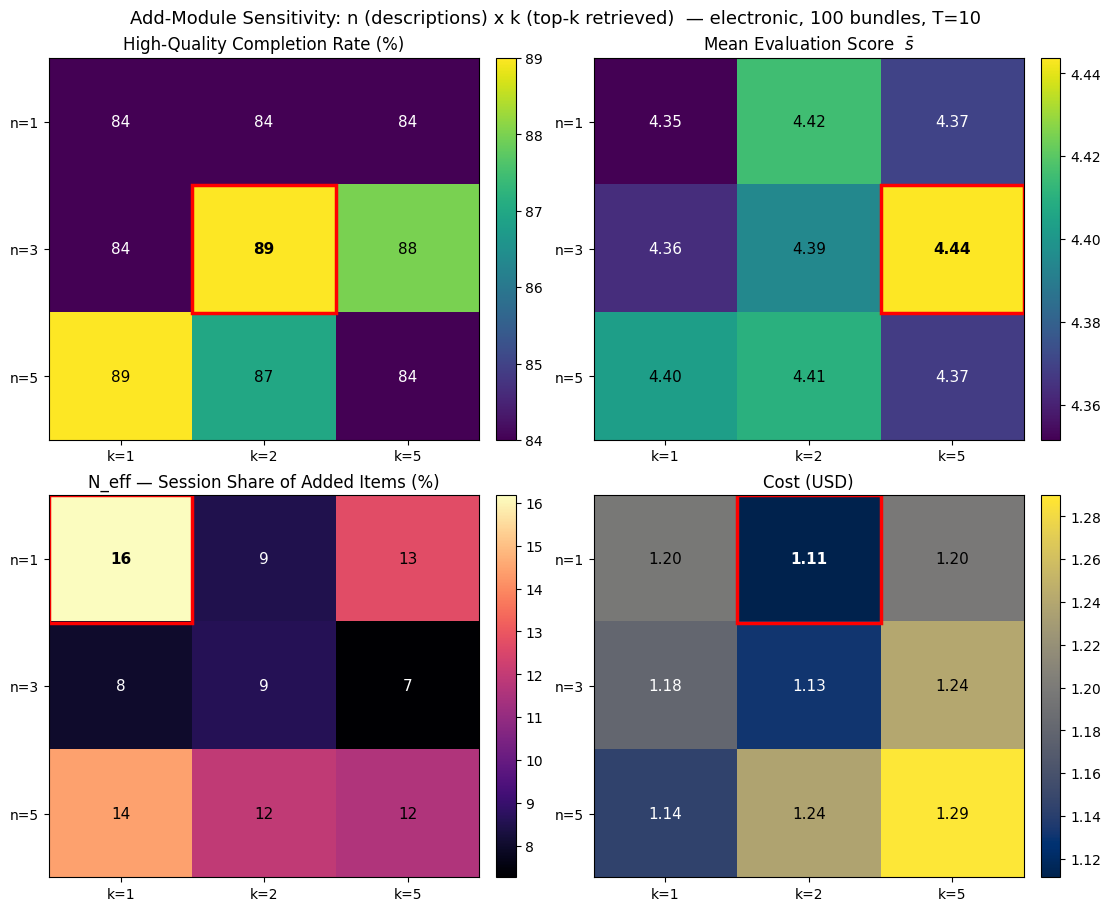

In [14]:
# 8. === Figures + summary table ===
import pandas as pd
plot_heatmaps(results, save=str(OUTPUT_DIR / "sweep_heatmaps.png"))
print("Figure saved under:", OUTPUT_DIR)
df = pd.DataFrame(results)
df["completion_%"] = (100*df["completion_rate"]).round(1)
print("Per-config summary (Reviewer-4 avg-iterations included):")
print(df[["n","k","completion_%","s_bar","avg_iterations","cost_usd"]].to_string(index=False))
plt.show()

In [10]:
# 9. Download the output folder (pkls, sweep_results.json, figures) as a zip.
# Safe to run any time, including mid-sweep -- it just archives whatever exists so far.
import shutil
from google.colab import files
zip_path = shutil.make_archive("add_module_sweep_output", "zip", str(OUTPUT_DIR))
print("zipped:", zip_path)
files.download(zip_path)

zipped: /content/add_module_sweep_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

> **Add Module.** Given a bundle flagged for augmentation, the module first prompts the LLM to
> generate **$n$ candidate item descriptions** — each a product-type profile representing a distinct
> way to improve the bundle. Each description is embedded and used to retrieve its **top-$k$**
> semantically-nearest catalog items (cosine similarity over `e5-large-v2` token embeddings),
> yielding **$n \times k$** retrieved candidates, which are unioned with the bundle's remaining
> session items to form the candidate pool. A final LLM call selects the single best addition. We
> use **$n=3$, $k=2$** (six retrieved candidates). *Parameter analysis (Fig. X):* on the electronic
> domain (100 bundles, $T=10$), completion rate and mean evaluation score $\bar{s}$ **plateau** by
> $n{=}3, k{=}2$, while cost and pool size keep growing and the effective session contribution
> $N_\text{eff}$ (share of added items drawn from the user's own session) **declines** as $n\times k$
> increases — larger pools dilute the original session signal for no quality gain. We therefore fix
> $n=3, k=2$.

*(Update Fig. X / the exact numbers from this run's `output/` figures.)*

## Corrected Add-Module prose (paste into the paper's Parameter Analysis section)

> **Add Module.** Given a bundle flagged for augmentation, the module first prompts the LLM to
> generate **$n$ candidate item descriptions** — each a product-type profile representing a distinct
> way to improve the bundle. Each description is embedded and used to retrieve its **top-$k$**
> semantically-nearest catalog items (cosine similarity over `e5-large-v2` token embeddings),
> yielding **$n \times k$** retrieved candidates, which are unioned with the bundle's remaining
> session items to form the candidate pool. A final LLM call selects the single best addition. We
> use **$n=3$, $k=2$** (six retrieved candidates). *Parameter analysis (Fig. X):* on the electronic
> domain (100 bundles, $T=10$), completion rate and mean evaluation score $\bar{s}$ **plateau** by
> $n{=}3, k{=}2$, while cost keeps growing with the candidate pool — larger settings add cost for no
> quality gain, so we fix $n=3, k=2$. We report completion rate and $\bar{s}$ for the sensitivity
> analysis; $N_\text{eff}$ is a corpus-level diversity measure and is unreliable on the subsampled
> grid, so we evaluate it only on the full dataset (§X).

*(Update Fig. X / the exact numbers from this run's `output/` figures.)*

In [15]:
# 12. (Recommended for the heavy full-dataset run) Persist output to Google Drive.
# Mounting Drive makes the hist_*_full.pkl caches survive Colab disconnects, so a timed-out
# sweep RESUMES instead of restarting from scratch. Run this AFTER the setup cells (1-6) and
# BEFORE the full-dataset runner below. (Skip it if you only want the subset sweep above.)
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
OUTPUT_DIR = Path("/content/drive/MyDrive/add_module_neff_output")  # <-- change path if you like
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output (hist_* caches, neff_sweep_results.json, figures) ->", OUTPUT_DIR)

Mounted at /content/drive
Output (hist_* caches, neff_sweep_results.json, figures) -> /content/drive/MyDrive/add_module_neff_output


## Full-dataset $N_\text{eff}$ sweep — fix $n=3$, vary $k\in\{2,5,10\}$ (Electronic, all bundles)

From the parameter analysis above, **$n=3$** already reaches the completion-rate plateau, and mean
score $\bar{s}$ is a weak discriminator (early-stopped bundles freeze their score, so $\bar{s}$ barely
moves across the grid). The open question is **corpus-level diversity**: does a larger retrieval width
$k$ *concentrate* item usage onto a few popular catalog items across the whole dataset? That only
becomes measurable at full scale, so we fix $n=3$ and sweep $k\in\{2,5,10\}$ over **all electronic
bundles**.

**$N_\text{eff}$ definition (matches `Workflow_analysis.ipynb`).** Flatten every item across all final
bundles into one multiset; let $p_i$ be the corpus-wide usage share of catalog item $i$. We report the
same distribution metrics used there — Shannon **entropy** $H=-\sum_i p_i\log_2 p_i$, **Gini**, and
**coverage** (share of the catalog that appears) — plus the interpretable **effective number of items**
$N_\text{eff}=2^{H}$. A *drop* in $N_\text{eff}$/entropy/coverage (or a *rise* in Gini) as $k$ grows is
the over-representation / long-tail-stifling effect. *(The notebook's earlier per-bundle `n_eff`
session-share is superseded by this corpus-level measure.)*

> **Heavy run:** ~1750 bundles $\times$ 3 configs $\times$ $T{=}10$ — a multi-hour, roughly \$60–100 job
> (larger $k$ = bigger candidate pools = pricier ADD prompts). It is **resumable**: a config whose
> `hist_electronic_n3_k{k}_full.pkl` already exists is loaded, not re-run — so you can run one $k$ per
> session. Distinct `*_full` filenames keep this from clobbering the subset-sweep caches above.

In [16]:
# 13. === Corpus-level N_eff (matches Workflow_analysis.ipynb) ===
from collections import Counter
import numpy as np

def gini(x):
    """Gini coefficient of a frequency array (0 = uniform, 1 = all mass on one item)."""
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

def corpus_representation(hist, total_items, stage="final"):
    """Corpus-level 'effective item representation' over ALL items in every bundle, exactly as in
    Workflow_analysis.ipynb: flatten item indices across the whole corpus, then measure how
    concentrated their usage is. stage='final' uses bundle_indices[-1]; 'initial' uses [0]."""
    _, _, indices, _, _, _ = hist
    bundles = indices[-1] if stage == "final" else indices[0]
    slob = [it for b in bundles for it in b]           # every item occurrence across the corpus
    counts = Counter(slob)
    freqs = np.array(sorted(counts.values(), reverse=True), dtype=float)
    p = freqs / freqs.sum()
    entropy = float(-np.sum(p * np.log2(p)))           # Shannon (base 2), as in Workflow_analysis
    return {
        "entropy": entropy,
        "n_eff": float(2 ** entropy),                  # effective # of items (perplexity of usage)
        "gini": float(gini(freqs)),
        "cv": float(np.std(freqs) / np.mean(freqs)),
        "unique_items": int(len(counts)),
        "coverage_pct": float(100 * len(counts) / total_items),
        "total_slots": int(freqs.sum()),
    }

In [18]:
# 14. === Full-dataset runner: n=3 fixed, k in {2,5,10}, ALL electronic bundles, T=10 ===
# Resumable: a config whose hist_*_full.pkl already exists is loaded, not re-run.
import json, pickle, time
from pathlib import Path

N_FIX = 3
K_SWEEP = [2, 5, 10] # change to [1,2,5]
T = 10
DOMAIN = "electronic"

load_data()   # loads e5-large-v2 + all catalog data (~1-2 min first time)
intents, item_ids, item_titles, session_ids, session_titles, product_lists = build_starting_inputs(DOMAIN, subset=None)
TOTAL_ITEMS = len(D.domain_items[DOMAIN_INDEX[DOMAIN]])
print(f"Prepared {len(intents)} {DOMAIN} seed bundles (FULL dataset). Catalog size = {TOTAL_ITEMS} items.")

ensure_output_dir()
neff_results = []
for k in K_SWEEP:
    tag = f"{DOMAIN}_n{N_FIX}_k{k}_full"
    pkl = OUTPUT_DIR / f"hist_{tag}.pkl"
    reset_tokens()
    if pkl.exists():
        with open(pkl, "rb") as f:
            res = pickle.load(f)
        cost, toks = None, None
        print(f"[n={N_FIX} k={k}] cached -> {pkl.name}")
    else:
        print(f"\n########## FULL RUN n={N_FIX}, k={k}  (T={T}, {len(intents)} bundles) ##########")
        t0 = time.time()
        res = await bundle_refinement_workflow(
            domain=DOMAIN, char=tag, prompts=load_domain_prompts(DOMAIN),
            starting_bundle_intents=intents, starting_bundle_item_ids=item_ids,
            starting_bundle_item_titles=item_titles, session_items_ids=session_ids,
            session_item_titles=session_titles, starting_product_list=product_lists,
            randomise="", num_iterations=T, n_expand=N_FIX, k_retrieve=k)
        cost, toks = current_cost_usd(), dict(TOKENS)
        with open(pkl, "wb") as f:          # persist under the _full name so re-runs resume from here
            pickle.dump(res, f)
        print(f"  done in {time.time()-t0:.0f}s | tokens_in={toks['in']} out={toks['out']} | cost=${cost:.3f}")

    base = metrics_for_run(res, session_ids)
    rep_f = corpus_representation(res, TOTAL_ITEMS, "final")
    rep_i = corpus_representation(res, TOTAL_ITEMS, "initial")
    row = dict(n=N_FIX, k=k, cost_usd=cost, tokens=toks,
               completion_rate=base["completion_rate"], s_bar=base["s_bar"],
               avg_iterations=base["avg_iterations"],
               **{f"final_{kk}": vv for kk, vv in rep_f.items()},
               **{f"init_{kk}": vv for kk, vv in rep_i.items()})
    neff_results.append(row)
    print(f"  -> N_eff(final)={rep_f['n_eff']:.1f}  entropy={rep_f['entropy']:.3f}  gini={rep_f['gini']:.3f}  "
          f"coverage={rep_f['coverage_pct']:.2f}%  (seed N_eff={rep_i['n_eff']:.1f})  "
          f"completion={100*base['completion_rate']:.1f}%")

with open(OUTPUT_DIR / "neff_sweep_results.json", "w") as f:
    json.dump(neff_results, f, indent=2, default=str)
print("\nSaved output/neff_sweep_results.json")

Prepared 1750 electronic seed bundles (FULL dataset). Catalog size = 3499 items.

########## FULL RUN n=3, k=2  (T=10, 1750 bundles) ##########
✅ Sending batch 1 — sleeping for 0s...

✅ Sending batch 2 — sleeping for 0s...

✅ Sending batch 3 — sleeping for 0s...

✅ Sending batch 4 — sleeping for 0s...

✅ Sending batch 5 — sleeping for 0s...

✅ Sending batch 6 — sleeping for 0s...

✅ Sending batch 7 — sleeping for 0s...

✅ Sending batch 8 — sleeping for 0s...

✅ Sending batch 9 — sleeping for 0s...

✅ Sending batch 10 — sleeping for 0s...

✅ Sending batch 11 — sleeping for 0s...

✅ Sending batch 12 — sleeping for 0s...

✅ Sending batch 13 — sleeping for 0s...

✅ Sending batch 14 — sleeping for 0s...

✅ Sending batch 1 — sleeping for 0s...

✅ Sending batch 2 — sleeping for 0s...

✅ Sending batch 3 — sleeping for 0s...

✅ Sending batch 4 — sleeping for 0s...

✅ Sending batch 5 — sleeping for 0s...

✅ Sending batch 6 — sleeping for 0s...

✅ Sending batch 7 — sleeping for 0s...

✅ Sending b

AttributeError: 'NoneType' object has no attribute 'split'

In [21]:
# 14b. === Single-k runner (SAFE: merges into neff_sweep_results.json, never overwrites) ===
# Use this to add ONE k (e.g. the k=1 "double take") without clobbering the k=2/k=5 results.
# Set K_ONE and run. Cached configs are loaded, not re-run; this k is upserted into the JSON.
import json, pickle, time
from pathlib import Path

K_ONE = 1                       # <-- the single k to (re)compute
N_FIX = 3
T = 10
DOMAIN = "electronic"

load_data()
intents, item_ids, item_titles, session_ids, session_titles, product_lists = build_starting_inputs(DOMAIN, subset=None)
TOTAL_ITEMS = len(D.domain_items[DOMAIN_INDEX[DOMAIN]])
ensure_output_dir()

tag = f"{DOMAIN}_n{N_FIX}_k{K_ONE}_full"
pkl = OUTPUT_DIR / f"hist_{tag}.pkl"
reset_tokens()
if pkl.exists():
    with open(pkl, "rb") as f:
        res = pickle.load(f)
    cost, toks = None, None
    print(f"[n={N_FIX} k={K_ONE}] cached -> {pkl.name}")
else:
    print(f"\n########## FULL RUN n={N_FIX}, k={K_ONE}  (T={T}, {len(intents)} bundles) ##########")
    t0 = time.time()
    res = await bundle_refinement_workflow(
        domain=DOMAIN, char=tag, prompts=load_domain_prompts(DOMAIN),
        starting_bundle_intents=intents, starting_bundle_item_ids=item_ids,
        starting_bundle_item_titles=item_titles, session_items_ids=session_ids,
        session_item_titles=session_titles, starting_product_list=product_lists,
        randomise="", num_iterations=T, n_expand=N_FIX, k_retrieve=K_ONE)
    cost, toks = current_cost_usd(), dict(TOKENS)
    with open(pkl, "wb") as f:               # persist under the _full name so re-runs resume
        pickle.dump(res, f)
    print(f"  done in {time.time()-t0:.0f}s | tokens_in={toks['in']} out={toks['out']} | cost=${cost:.3f}")

base = metrics_for_run(res, session_ids)
rep_f = corpus_representation(res, TOTAL_ITEMS, "final")
rep_i = corpus_representation(res, TOTAL_ITEMS, "initial")
row = dict(n=N_FIX, k=K_ONE, cost_usd=cost, tokens=toks,
           completion_rate=base["completion_rate"], s_bar=base["s_bar"],
           avg_iterations=base["avg_iterations"],
           **{f"final_{kk}": vv for kk, vv in rep_f.items()},
           **{f"init_{kk}": vv for kk, vv in rep_i.items()})

# --- MERGE (upsert by (n,k)) into the existing JSON instead of overwriting it ---
json_path = OUTPUT_DIR / "neff_sweep_results.json"
existing = json.load(open(json_path)) if json_path.exists() else []
existing = [r for r in existing if not (r.get("n") == N_FIX and r.get("k") == K_ONE)]
existing.append(row)
neff_results = sorted(existing, key=lambda r: (r["n"], r["k"]))   # feeds the figures cell (# 15)
with open(json_path, "w") as f:
    json.dump(neff_results, f, indent=2, default=str)

print(f"  -> N_eff(final)={rep_f['n_eff']:.1f}  entropy={rep_f['entropy']:.3f}  gini={rep_f['gini']:.3f}  "
      f"coverage={rep_f['coverage_pct']:.2f}%  (seed N_eff={rep_i['n_eff']:.1f})  "
      f"completion={100*base['completion_rate']:.1f}%")
print(f"merged into {json_path.name}; now contains k = {[r['k'] for r in neff_results]}")
print("Re-run the figures cell (# 15) to refresh neff_vs_k across all k.")


########## FULL RUN n=3, k=1  (T=10, 1750 bundles) ##########
✅ Sending batch 1 — sleeping for 0s...

✅ Sending batch 2 — sleeping for 0s...

✅ Sending batch 3 — sleeping for 0s...

✅ Sending batch 4 — sleeping for 0s...

✅ Sending batch 5 — sleeping for 0s...

✅ Sending batch 6 — sleeping for 0s...

✅ Sending batch 7 — sleeping for 0s...

✅ Sending batch 8 — sleeping for 0s...

✅ Sending batch 9 — sleeping for 0s...

✅ Sending batch 10 — sleeping for 0s...

✅ Sending batch 11 — sleeping for 0s...

✅ Sending batch 12 — sleeping for 0s...

✅ Sending batch 13 — sleeping for 0s...

✅ Sending batch 14 — sleeping for 0s...

✅ Sending batch 1 — sleeping for 0s...

✅ Sending batch 2 — sleeping for 0s...

✅ Sending batch 3 — sleeping for 0s...

✅ Sending batch 4 — sleeping for 0s...

✅ Sending batch 5 — sleeping for 0s...

✅ Sending batch 6 — sleeping for 0s...

✅ Sending batch 7 — sleeping for 0s...

✅ Sending batch 8 — sleeping for 0s...

✅ Sending batch 9 — sleeping for 0s...

✅ Sending ba

saved output/neff_vs_k.{png,pdf}

Full-dataset n=3 x k sweep (corpus-level N_eff = 2^entropy):
 n  k  completion_%    s_bar  cost_usd  final_n_eff  final_entropy  final_gini  final_cv  final_coverage_pct  final_unique_items
 3  1          90.0 4.464017 17.477154  1820.726204      10.830298    0.369162  1.078648           70.963132                2483


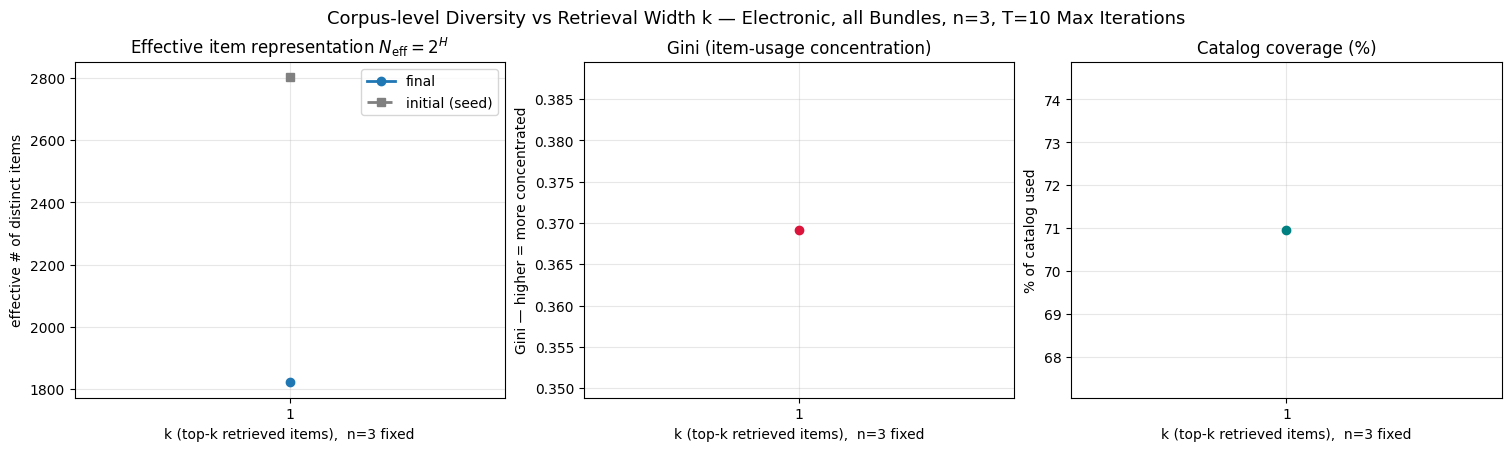

In [22]:
# 15. === N_eff-vs-k figures + summary table ===
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(neff_results).sort_values("k")
ks = df["k"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
axes[0].plot(ks, df["final_n_eff"], "o-", lw=2, label="final")
axes[0].plot(ks, df["init_n_eff"], "s--", lw=2, color="gray", label="initial (seed)")
axes[0].set_title(r"Effective item representation $N_{\mathrm{eff}}=2^{H}$")
axes[0].set_ylabel("effective # of distinct items"); axes[0].legend()
axes[1].plot(ks, df["final_gini"], "o-", lw=2, color="crimson")
axes[1].set_title("Gini (item-usage concentration)"); axes[1].set_ylabel("Gini — higher = more concentrated")
axes[2].plot(ks, df["final_coverage_pct"], "o-", lw=2, color="teal")
axes[2].set_title("Catalog coverage (%)"); axes[2].set_ylabel("% of catalog used")
for ax in axes:
    ax.set_xticks(ks); ax.set_xlabel("k (top-k retrieved items),  n=3 fixed"); ax.grid(alpha=0.3)
fig.suptitle("Corpus-level Diversity vs Retrieval Width k — Electronic, all Bundles, n=3, T=10 Max Iterations",
             fontsize=13)
fig.savefig(OUTPUT_DIR / "neff_vs_k.png", dpi=150, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "neff_vs_k.pdf", bbox_inches="tight")
print("saved output/neff_vs_k.{png,pdf}")

show = df[["n", "k", "completion_rate", "s_bar", "cost_usd", "final_n_eff", "final_entropy",
           "final_gini", "final_cv", "final_coverage_pct", "final_unique_items"]].copy()
show["completion_%"] = (100 * show["completion_rate"]).round(1)
show = show[["n", "k", "completion_%", "s_bar", "cost_usd", "final_n_eff", "final_entropy",
             "final_gini", "final_cv", "final_coverage_pct", "final_unique_items"]]
print("\nFull-dataset n=3 x k sweep (corpus-level N_eff = 2^entropy):")
print(show.to_string(index=False))
plt.show()

In [24]:
# 9. Download the output folder (pkls, sweep_results.json, figures) as a zip.
# Safe to run any time, including mid-sweep -- it just archives whatever exists so far.
import shutil
from google.colab import files
zip_path = shutil.make_archive("add_module_full_sweep_output", "zip", str(OUTPUT_DIR))
print("zipped:", zip_path)
files.download(zip_path)

zipped: /content/add_module_full_sweep_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

found 3 full-dataset history file(s) in /content/drive/MyDrive/add_module_neff_output:
  n=3 k=1  <- hist_electronic_n3_k1_full.pkl
  n=3 k=2  <- hist_electronic_n3_k2_full.pkl
  n=3 k=5  <- hist_electronic_n3_k5_full.pkl

Rebuilt full-dataset n=3 x k sweep (from history files on disk):
 n  k  completion_%    s_bar  avg_iterations  init_n_eff  final_n_eff  final_entropy  final_gini  final_coverage_pct  final_unique_items
 3  1          90.0 4.464017        4.457335 2802.517838  1820.726204      10.830298    0.369162           70.963132                2483
 3  2          91.5 4.499634        4.218141 2802.517838  1837.657603      10.843652    0.366175           71.306087                2495
 3  5          92.1 4.500811        4.211624 2802.517838  1798.535090      10.812607    0.371690           71.134610                2489

saved /content/drive/MyDrive/add_module_neff_output/neff_vs_k_rebuilt.{png,pdf}
refreshed /content/drive/MyDrive/add_module_neff_output/neff_sweep_results.json fro

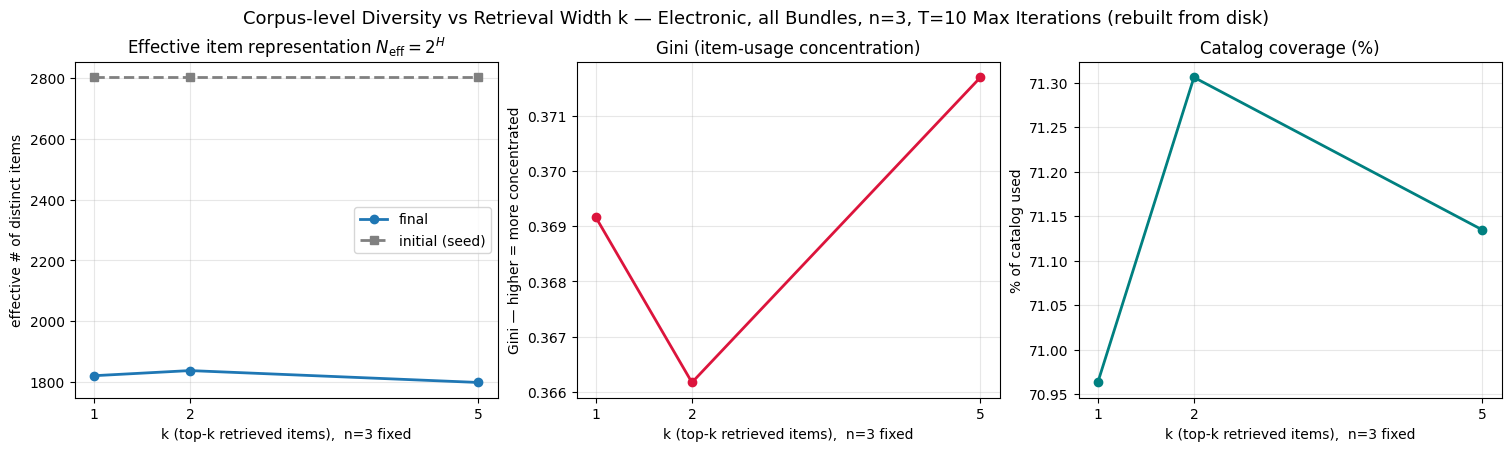

In [25]:
# 16. === Rebuild table + N_eff-vs-k plots from every hist_*_full.pkl on disk ===
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DOMAIN_REBUILD = "electronic"
TOTAL_ITEMS_REBUILD = len(D.domain_items[DOMAIN_INDEX[DOMAIN_REBUILD]]) if D.loaded else None
if TOTAL_ITEMS_REBUILD is None:
    load_data()
    TOTAL_ITEMS_REBUILD = len(D.domain_items[DOMAIN_INDEX[DOMAIN_REBUILD]])

pattern = re.compile(rf"hist_{DOMAIN_REBUILD}_n(\d+)_k(\d+)_full\.pkl$")
found = sorted(
    (int(m.group(1)), int(m.group(2)), p)
    for p in OUTPUT_DIR.glob(f"hist_{DOMAIN_REBUILD}_n*_k*_full.pkl")
    if (m := pattern.search(p.name))
)
print(f"found {len(found)} full-dataset history file(s) in {OUTPUT_DIR}:")
for n, k, p in found:
    print(f"  n={n} k={k}  <- {p.name}")

rebuilt_rows = []
for n, k, p in found:
    with open(p, "rb") as f:
        res = pickle.load(f)
    base = metrics_for_run(res, None)
    rep_f = corpus_representation(res, TOTAL_ITEMS_REBUILD, "final")
    rep_i = corpus_representation(res, TOTAL_ITEMS_REBUILD, "initial")
    rebuilt_rows.append(dict(
        n=n, k=k,
        completion_rate=base["completion_rate"], s_bar=base["s_bar"],
        avg_iterations=base["avg_iterations"],
        **{f"final_{kk}": vv for kk, vv in rep_f.items()},
        **{f"init_{kk}": vv for kk, vv in rep_i.items()},
    ))

df = pd.DataFrame(rebuilt_rows).sort_values("k").reset_index(drop=True)
show = df[["n", "k", "completion_rate", "s_bar", "avg_iterations", "final_n_eff", "final_entropy",
           "final_gini", "final_coverage_pct", "final_unique_items", "init_n_eff"]].copy()
show["completion_%"] = (100 * show["completion_rate"]).round(1)
show = show[["n", "k", "completion_%", "s_bar", "avg_iterations", "init_n_eff", "final_n_eff",
             "final_entropy", "final_gini", "final_coverage_pct", "final_unique_items"]]
print("\nRebuilt full-dataset n=3 x k sweep (from history files on disk):")
print(show.to_string(index=False))

ks = df["k"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
axes[0].plot(ks, df["final_n_eff"], "o-", lw=2, label="final")
axes[0].plot(ks, df["init_n_eff"], "s--", lw=2, color="gray", label="initial (seed)")
axes[0].set_title(r"Effective item representation $N_{\mathrm{eff}}=2^{H}$")
axes[0].set_ylabel("effective # of distinct items"); axes[0].legend()
axes[1].plot(ks, df["final_gini"], "o-", lw=2, color="crimson")
axes[1].set_title("Gini (item-usage concentration)"); axes[1].set_ylabel("Gini — higher = more concentrated")
axes[2].plot(ks, df["final_coverage_pct"], "o-", lw=2, color="teal")
axes[2].set_title("Catalog coverage (%)"); axes[2].set_ylabel("% of catalog used")
for ax in axes:
    ax.set_xticks(ks); ax.set_xlabel(f"k (top-k retrieved items),  n={df['n'].iloc[0]} fixed"); ax.grid(alpha=0.3)
fig.suptitle(f"Corpus-level Diversity vs Retrieval Width k — {DOMAIN_REBUILD.capitalize()}, all Bundles, "
             f"n={df['n'].iloc[0]}, T=10 Max Iterations (rebuilt from disk)", fontsize=13)
fig.savefig(OUTPUT_DIR / "neff_vs_k_rebuilt.png", dpi=150, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "neff_vs_k_rebuilt.pdf", bbox_inches="tight")
print(f"\nsaved {OUTPUT_DIR}/neff_vs_k_rebuilt.{{png,pdf}}")

# Also refresh the canonical JSON from the rebuilt table, so downstream cells stay consistent.
with open(OUTPUT_DIR / "neff_sweep_results.json", "w") as f:
    json.dump(rebuilt_rows, f, indent=2, default=str)
print(f"refreshed {OUTPUT_DIR}/neff_sweep_results.json from disk ({len(rebuilt_rows)} configs)")
plt.show()

done in 10351s | tokens_in=41469187 out=19275942 | cost=$17.786
  -> N_eff(final)=1798.5  entropy=10.813  gini=0.372  coverage=71.13%  (seed N_eff=2802.5)  completion=92.1%

for k=5


  done in 9949s | tokens_in=40202751 out=18276862 | cost=$16.997
  -> N_eff(final)=1837.7  entropy=10.844  gini=0.366  coverage=71.31%  (seed N_eff=2802.5)  completion=91.5%

for k = 2


  done in 10088s | tokens_in=41741751 out=18693152 | cost=$17.477
  -> N_eff(final)=1820.7  entropy=10.830  gini=0.369  coverage=70.96%  (seed N_eff=2802.5)  completion=90.0%

for k = 1